# Proyek Analisis Data: Bike-sharing-dataset
- **Nama:** Vina Widiasari
- **Email:** cdcc229d6x0985@student.devacademy.id
- **ID Dicoding:** CDCC229D6X0985

## Menentukan Pertanyaan Bisnis

- Bagaimana pengaruh variabel kondisi cuaca terhadap jumlah total penyewaan sepeda per hari?
- Bagaimana perbandingan rata-rata penyewaan sepeda antara hari libur dan hari kerja?
- Kapan terjadi rata-rata jumlah penyewaan sepeda tertinggi dan terendah dalam sehari?

## Import Semua Packages/Library yang Digunakan

In [141]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [142]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [143]:
day_df = pd.read_csv('/content/drive/MyDrive/data/day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [144]:
hour_df = pd.read_csv('/content/drive/MyDrive/data/hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset yang digunakan merupakan data historis penyewaan sepeda dari sistem Capital Bikeshare di Washington D.C., USA selama periode 2011–2012.
- Data disajikan dalam dua tingkat granularitas, yaitu harian (day.csv) dan per jam (hour.csv), sehingga memungkinkan analisis baik secara makro maupun detail.
- Jumlah observasi terdiri dari 731 data harian dan 17.379 data per jam.
- Dataset ini tidak hanya memuat jumlah penyewaan sepeda (cnt), tetapi juga faktor-faktor yang berpotensi memengaruhi permintaan, seperti:
  - Kondisi cuaca (weathersit, temp, hum, windspeed)
  - Waktu (yr, mnth, weekday, hr)
  - Kondisi kalender (holiday, workingday, season)
- Variabel cnt merupakan jumlah total penyewaan yang merupakan agregasi dari dua tipe pengguna, yaitu casual dan registered.
- Nilai pada beberapa variabel seperti temp, atemp, hum, dan windspeed telah dinormalisasi, sehingga perlu diperhatikan dalam interpretasi analisis.

### Assessing Data

In [145]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [146]:
day_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
holiday,0
weekday,0
workingday,0
weathersit,0
temp,0


In [147]:
print("Jumlah duplikasi: ", day_df.duplicated().sum())

Jumlah duplikasi:  0


In [148]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [149]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [150]:
hour_df.isna().sum()

,0
instant,0
dteday,0
season,0
yr,0
mnth,0
hr,0
holiday,0
weekday,0
workingday,0
weathersit,0


In [151]:
print("Jumlah duplikasi: ", hour_df.duplicated().sum())

Jumlah duplikasi:  0


In [152]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Dataset harian (731 data) dan dataset per jam (17.379 data) tidak memiliki missing values, sehingga data tergolong lengkap untuk dianalisis.
- Kolom dteday masih bertipe object dan perlu dikonversi menjadi datetime, serta beberapa variabel, yaitu season, weathersit, holiday, dan workingday masih berupa numerik meskipun bersifat kategorikal.
- Jumlah penyewaan sepeda (cnt) memiliki variasi yang tinggi, baik pada tingkat harian (22–8714) maupun per jam (1–977), yang menunjukkan fluktuasi penggunaan yang signifikan.
- Pengguna registered jauh lebih dominan dibandingkan casual, yang mengindikasikan bahwa layanan lebih banyak digunakan untuk kebutuhan rutin.
- Terdapat inkonsistensi antara dataset harian dan per jam, khususnya pada variabel weathersit, di mana kondisi cuaca ekstrem hanya muncul pada data per jam.
- Ditemukan nilai yang tidak umum, seperti registered = 0 dan hum = 0, yang mengindikasikan potensi anomali atau hasil preprocessing pada data.
- Variabel waktu disajikan dalam beberapa bentuk (dteday, yr, mnth, weekday), sehingga berpotensi menimbulkan redundansi informasi dalam analisis lanjutan.
- Tingginya variabilitas data menunjukkan bahwa analisis berbasis waktu (time series) relevan untuk dilakukan pada tahap berikutnya.

### Cleaning Data

In [153]:
# Konversi kolom tanggal ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Konversi variabel kategorikal dari numerik ke tipe category
categorical_cols = ['season', 'yr', 'mnth', 'weekday', 'weathersit', 'holiday', 'workingday']
for col in categorical_cols:
    day_df[col] = day_df[col].astype('category')
    hour_df[col] = hour_df[col].astype('category')

# Drop kolom indeks yang tidak digunakan
day_df.drop(columns=['instant'], inplace=True)
hour_df.drop(columns=['instant'], inplace=True)

In [154]:
print("Jumlah hum = 0 (day_df): ", (day_df['hum'] == 0).sum())
print("Jumlah hum = 0 (hour_df): ", (hour_df['hum'] == 0).sum())

Jumlah hum = 0 (day_df):  1
Jumlah hum = 0 (hour_df):  22


In [155]:
day_df = day_df[day_df['hum'] > 0]
print("Jumlah hum = 0 (day_df): ", (day_df['hum'] == 0).sum())
hour_df = hour_df[hour_df['hum'] > 0]
print("Jumlah hum = 0 (hour_df): ", (hour_df['hum'] == 0).sum())

Jumlah hum = 0 (day_df):  0
Jumlah hum = 0 (hour_df):  0


In [156]:
print(f"Day DF Match: {(day_df.cnt == day_df.casual + day_df.registered).all()}")
print(f"Hour DF Match: {(hour_df.cnt == hour_df.casual + hour_df.registered).all()}")

Day DF Match: True
Hour DF Match: True


In [157]:
print("Rentang jam:", hour_df['hr'].min(),"-", hour_df['hr'].max())

Rentang jam: 0 - 23


In [158]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 730 entries, 0 to 730
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      730 non-null    datetime64[ns]
 1   season      730 non-null    category      
 2   yr          730 non-null    category      
 3   mnth        730 non-null    category      
 4   holiday     730 non-null    category      
 5   weekday     730 non-null    category      
 6   workingday  730 non-null    category      
 7   weathersit  730 non-null    category      
 8   temp        730 non-null    float64       
 9   atemp       730 non-null    float64       
 10  hum         730 non-null    float64       
 11  windspeed   730 non-null    float64       
 12  casual      730 non-null    int64         
 13  registered  730 non-null    int64         
 14  cnt         730 non-null    int64         
dtypes: category(7), datetime64[ns](1), float64(4), int64(3)
memory usage: 57.7 KB


In [159]:
day_df.describe()

,dteday,temp,atemp,hum,windspeed,casual,registered,cnt
count,730,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,2012-01-01 09:45:51.780822016,0.495530,0.474475,0.628754,0.190388,849.275342,3660.390411,4509.665753
min,2011-01-01 00:00:00,0.059130,0.079070,0.187917,0.022392,2.000000,20.000000,22.000000
25%,2011-07-03 06:00:00,0.336875,0.337794,0.520521,0.134950,316.250000,2502.250000,3169.750000
50%,2012-01-01 12:00:00,0.499167,0.487364,0.627083,0.180971,717.000000,3664.500000,4548.500000
75%,2012-07-01 18:00:00,0.655625,0.608916,0.730313,0.233207,1096.500000,4783.250000,5966.000000
max,2012-12-31 00:00:00,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,NaN,0.183134,0.163040,0.140614,0.077506,686.449738,1557.149836,1933.194931


In [160]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17357 entries, 0 to 17378
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   dteday      17357 non-null  datetime64[ns]
 1   season      17357 non-null  category      
 2   yr          17357 non-null  category      
 3   mnth        17357 non-null  category      
 4   hr          17357 non-null  int64         
 5   holiday     17357 non-null  category      
 6   weekday     17357 non-null  category      
 7   workingday  17357 non-null  category      
 8   weathersit  17357 non-null  category      
 9   temp        17357 non-null  float64       
 10  atemp       17357 non-null  float64       
 11  hum         17357 non-null  float64       
 12  windspeed   17357 non-null  float64       
 13  casual      17357 non-null  int64         
 14  registered  17357 non-null  int64         
 15  cnt         17357 non-null  int64         
dtypes: category(7), datetime64[

In [161]:
hour_df.describe()

,dteday,hr,temp,atemp,hum,windspeed,casual,registered,cnt
count,17357,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000,17357.000000
mean,2012-01-02 13:12:48.035950848,11.545889,0.497124,0.475889,0.628024,0.190007,35.718788,153.948551,189.667339
min,2011-01-01 00:00:00,0.000000,0.020000,0.000000,0.080000,0.000000,0.000000,0.000000,1.000000
25%,2011-07-05 00:00:00,6.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,2012-01-03 00:00:00,12.000000,0.500000,0.484800,0.630000,0.194000,17.000000,116.000000,142.000000
75%,2012-07-02 00:00:00,18.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,2012-12-31 00:00:00,23.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,NaN,6.914537,0.192635,0.171921,0.191754,0.122342,49.321693,151.382189,181.409297


**Insight:**
- Tidak ditemukan missing values pada kedua dataset, sehingga tidak diperlukan penanganan nilai kosong.
- Kolom dteday berhasil dikonversi menjadi tipe datetime untuk mendukung analisis berbasis waktu.
- Variabel seperti season, yr, mnth, weathersit, holiday, weekday, dan workingday telah diubah menjadi tipe kategorikal agar sesuai dengan karakteristik data dan menghindari kesalahan interpretasi sebagai numerik.
- Kolom instant dihapus karena tidak memberikan informasi yang relevan untuk analisis.
- Ditemukan nilai anomali pada variabel hum sebesar 0 sebanyak 22 data (0,13%), yang dianggap tidak realistis sehingga data tersebut dihapus.
- Tidak ditemukan inkonsistensi pada data, dibuktikan dengan kesesuaian antara cnt dengan penjumlahan casual dan registered.
- Variabel hr berada dalam rentang yang valid (0–23), sehingga tidak ditemukan kesalahan pada data waktu.

## Exploratory Data Analysis (EDA)

### Explore Data day_df

In [162]:
day_df['temp_c'] = day_df['temp'] * 41
day_df['atemp_c'] = day_df['atemp'] * 50
day_df['hum_percent'] = day_df['hum'] * 100
day_df['windspeed_real'] = day_df['windspeed'] * 67

In [163]:
weather_labels = {
    1: 'Clear',
    2: 'Mist/Cloudy',
    3: 'Light Rain/Snow',
    4: 'Heavy Rain/Snow'
}
day_df['weather_label'] = day_df['weathersit'].map(weather_labels)

In [164]:
weather_daily = (
    day_df
    .groupby('weather_label')['cnt']
    .agg(mean_cnt='mean', median_cnt='median', min_cnt='min', max_cnt='max', n='count')
    .reset_index()
    .sort_values('mean_cnt', ascending=False)
)
weather_daily

/tmp/ipykernel_26559/2346371856.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('weather_label')['cnt']


,weather_label,mean_cnt,median_cnt,min_cnt,max_cnt,n
0,Clear,4876.786177,4844.0,431,8714,463
1,Mist/Cloudy,4035.862348,4040.0,605,8362,247
2,Light Rain/Snow,1862.300000,1829.5,22,4639,20


In [165]:
day_df['temp_bin'] = pd.qcut(day_df['temp'], q=4)  # kuartil

temp_effect = (
    day_df
    .groupby('temp_bin')['cnt']
    .mean()
    .reset_index()
    .sort_values('temp_bin')
)
temp_effect

/tmp/ipykernel_26559/1343490087.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('temp_bin')['cnt']


,temp_bin,cnt
0,"(0.0581, 0.337]",2615.076503
1,"(0.337, 0.499]",4206.148352
2,"(0.499, 0.656]",5591.104396
3,"(0.656, 0.862]",5630.584699


In [166]:
day_df['hum_bin'] = pd.qcut(day_df['hum'], q=4)

hum_effect = (
    day_df
    .groupby('hum_bin')['cnt']
    .mean()
    .reset_index()
    .sort_values('hum_bin')
)
hum_effect

/tmp/ipykernel_26559/154428161.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('hum_bin')['cnt']


,hum_bin,cnt
0,"(0.187, 0.521]",4398.327869
1,"(0.521, 0.627]",4851.703297
2,"(0.627, 0.73]",4913.571429
3,"(0.73, 0.972]",3879.136612


In [167]:
day_df['wind_bin'] = pd.qcut(day_df['windspeed'], q=4)

wind_effect = (
    day_df
    .groupby('wind_bin')['cnt']
    .mean()
    .reset_index()
    .sort_values('wind_bin')
)
wind_effect

/tmp/ipykernel_26559/2141517236.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('wind_bin')['cnt']


,wind_bin,cnt
0,"(0.0214, 0.135]",4922.934783
1,"(0.135, 0.181]",4934.646409
2,"(0.181, 0.233]",4186.269231
3,"(0.233, 0.507]",3995.431694


In [168]:
corr_weather = day_df[['cnt','temp','hum','windspeed']].corr()
corr_weather

,cnt,temp,hum,windspeed
cnt,1.000000,0.627774,-0.114625,-0.232790
temp,0.627774,1.000000,0.125160,-0.157338
hum,-0.114625,0.125160,1.000000,-0.246366
windspeed,-0.232790,-0.157338,-0.246366,1.000000


**Insight:**
- Kondisi cuaca memiliki pengaruh signifikan terhadap jumlah penyewaan sepeda, di mana cuaca yang lebih baik menghasilkan tingkat penyewaan yang lebih tinggi.
- Rata-rata penyewaan tertinggi terjadi pada kondisi cuaca cerah, menurun pada kondisi berawan, dan turun drastis pada kondisi hujan atau salju ringan.
- Variabel suhu (temp) menunjukkan korelasi positif cukup kuat (0.627) terhadap jumlah penyewaan, yang mengindikasikan bahwa suhu yang lebih tinggi mendorong peningkatan penggunaan sepeda.
- Analisis berbasis kelompok menunjukkan bahwa semakin tinggi suhu, rata-rata penyewaan cenderung meningkat secara konsisten.
- Variabel kelembapan (hum) memiliki korelasi negatif lemah (-0.115), dengan pola bahwa penyewaan cenderung meningkat pada tingkat kelembapan menengah dan menurun pada kelembapan yang terlalu tinggi.
- Variabel kecepatan angin (windspeed) juga menunjukkan korelasi negatif (-0.233), yang mengindikasikan bahwa angin yang lebih kencang cenderung mengurangi minat penggunaan sepeda.
- Dibandingkan variabel lainnya, suhu merupakan faktor cuaca yang paling dominan, sedangkan kelembapan dan kecepatan angin memiliki pengaruh yang lebih kecil.
- Secara keseluruhan, kondisi yang mendukung peningkatan penyewaan sepeda adalah suhu yang lebih hangat, kelembapan pada tingkat menengah, dan kecepatan angin yang rendah.

### Explore Data hour_df

In [190]:
hour_df['temp_c'] = hour_df['temp'] * 41
hour_df['atemp_c'] = hour_df['atemp'] * 50
hour_df['hum_percent'] = hour_df['hum'] * 100
hour_df['windspeed_real'] = hour_df['windspeed'] * 67

In [191]:
hour_df['weather_label'] = hour_df['weathersit'].map(weather_labels)

In [192]:
hour_df['day_type'] = hour_df['workingday'].map({
    0: 'Hari Libur',
    1: 'Hari Kerja'
})

In [195]:
hour_df['usage_category'] = pd.cut(
    hour_df['cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

In [194]:
hourly_working = (
    hour_df
    .groupby(['workingday','hr'])['cnt']
    .mean()
    .reset_index()
)
hourly_working

/tmp/ipykernel_26559/3050457228.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(['workingday','hr'])['cnt']


,workingday,hr,cnt
0,0,0,90.800000
1,0,1,69.508696
2,0,2,53.171053
3,0,3,25.775330
4,0,4,8.264317
5,0,5,8.689189
6,0,6,18.742358
7,0,7,43.406926
8,0,8,105.653680
9,0,9,171.623377


In [170]:
weekday_data = hourly_working[hourly_working['workingday'] == 1]
weekday_sorted = weekday_data.sort_values(by='cnt', ascending=False)

weekday_sorted

,workingday,hr,cnt
41,1,17,526.122490
42,1,18,493.052314
32,1,8,477.880808
43,1,19,348.989940
40,1,16,293.668675
31,1,7,291.125253
44,1,20,250.144869
33,1,9,241.957576
39,1,15,201.708249
36,1,12,201.157258


In [171]:
weekend_data = hourly_working[hourly_working['workingday'] == 0]
weekend_sorted = weekend_data.sort_values(by='cnt', ascending=False)

weekend_sorted

,workingday,hr,cnt
13,0,13,372.731602
12,0,12,366.259740
14,0,14,364.645022
15,0,15,358.813853
16,0,16,352.727273
17,0,17,323.549784
11,0,11,315.316017
18,0,18,281.056522
10,0,10,255.909091
19,0,19,231.673913


In [172]:
hourly_mean = (
    hour_df
    .groupby('hr')['cnt']
    .mean()
    .reset_index()
    .sort_values('cnt', ascending=False)
)
hourly_mean

,hr,cnt
17,17,461.932785
18,18,425.983494
8,8,359.444904
16,16,312.382716
19,19,311.874828
13,13,253.993132
12,12,253.617607
15,15,251.559066
14,14,241.263736
20,20,226.288858


In [173]:
peak_hour = hourly_mean.iloc[0]
lowest_hour = hourly_mean.iloc[-1]

print(f"Peak Hour (Jam Tertinggi):")
print(f"Jam: {int(peak_hour['hr'])}")
print(f"Rata-rata Penyewaan: {peak_hour['cnt']:.2f}")

print(f"\nLowest Hour (Jam Terendah):")
print(f"Jam: {int(lowest_hour['hr'])}")
print(f"Rata-rata Penyewaan: {lowest_hour['cnt']:.2f}")

Peak Hour (Jam Tertinggi):
Jam: 17
Rata-rata Penyewaan: 461.93

Lowest Hour (Jam Terendah):
Jam: 4
Rata-rata Penyewaan: 6.35


**Insight:**
- Rata-rata penyewaan sepeda tertinggi terjadi pada pukul 17.00 dengan rata-rata sekitar 461,93 penyewaan, yang menunjukkan adanya lonjakan penggunaan pada jam pulang kerja (evening rush hour).
- Rata-rata penyewaan terendah terjadi pada pukul 04.00 dengan rata-rata sekitar 6,35 penyewaan, yang mengindikasikan aktivitas penggunaan sepeda sangat rendah pada dini hari.
- Pada hari kerja (workingday), puncak penyewaan juga terjadi pada pukul 17.00 dengan rata-rata lebih tinggi, yaitu sekitar 526,12 penyewaan, yang menunjukkan dominasi penggunaan untuk kebutuhan komuter (berangkat/pulang kerja).
- Pada hari libur (weekday), puncak penyewaan terjadi pada pukul 13.00 dengan rata-rata sekitar 372,73 penyewaan, yang mengindikasikan pola penggunaan yang lebih santai dan cenderung terjadi pada siang hari.
- Secara keseluruhan, rata-rata penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur, yang menunjukkan bahwa layanan bike sharing lebih banyak dimanfaatkan untuk aktivitas rutin dibandingkan rekreasi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh variabel kondisi cuaca terhadap jumlah total penyewaan sepeda per hari?

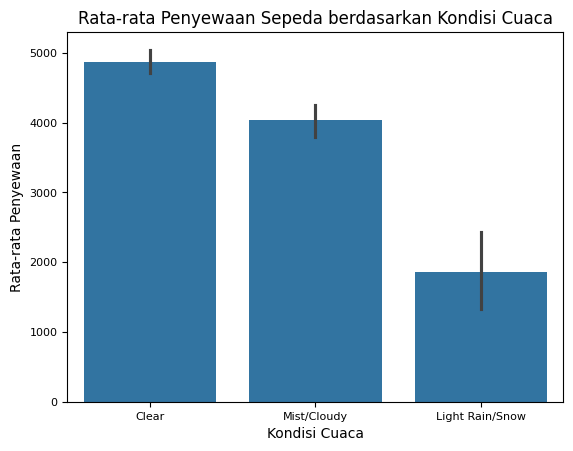

In [174]:
sns.barplot(data=day_df, x='weather_label', y='cnt')
plt.title('Rata-rata Penyewaan Sepeda berdasarkan Kondisi Cuaca')
plt.xlabel('Kondisi Cuaca')
plt.ylabel('Rata-rata Penyewaan')
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.show()

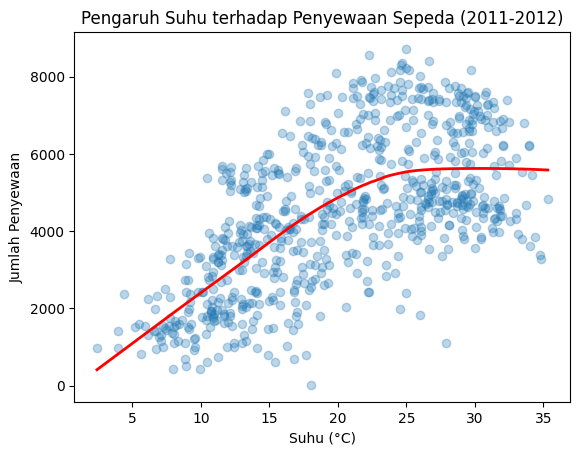

In [175]:
sns.regplot(data=day_df,
            x='temp_c',
            y='cnt',
            lowess=True,
            scatter_kws={'alpha':0.3},
            line_kws={'color':'red', 'linewidth':2})

plt.title('Pengaruh Suhu terhadap Penyewaan Sepeda (2011-2012)')
plt.xlabel('Suhu (°C)')
plt.ylabel('Jumlah Penyewaan')

plt.show()

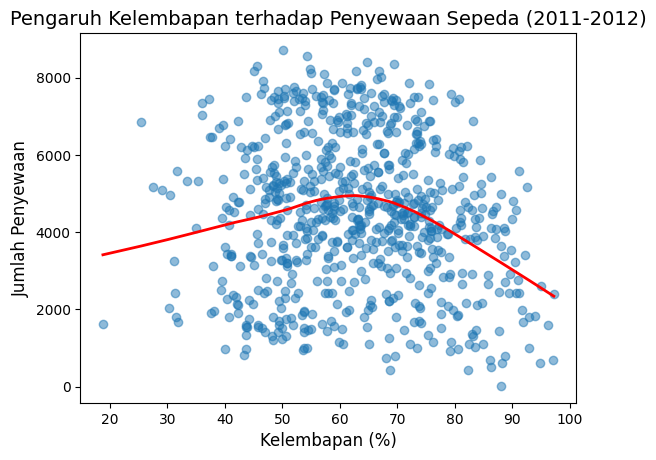

In [176]:
sns.regplot(data=day_df,
            x='hum_percent',
            y='cnt',
            lowess=True,
            scatter_kws={'alpha':0.5},
            line_kws={'color':'red', 'linewidth':2})

plt.title('Pengaruh Kelembapan terhadap Penyewaan Sepeda (2011-2012)', fontsize=14)
plt.xlabel('Kelembapan (%)', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)

plt.show()

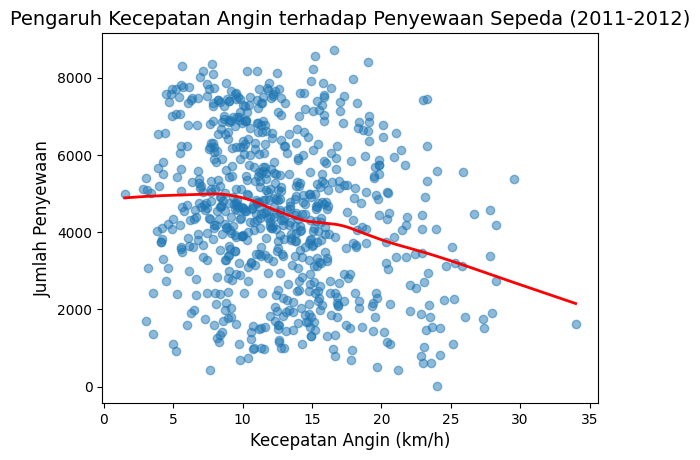

In [177]:
sns.regplot(data=day_df,
            x='windspeed_real',
            y='cnt',
            lowess=True,
            scatter_kws={'alpha': 0.5},
            line_kws={'color': 'red', 'linewidth': 2})

plt.title('Pengaruh Kecepatan Angin terhadap Penyewaan Sepeda (2011-2012)', fontsize=14)
plt.xlabel('Kecepatan Angin (km/h)', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)

plt.show()

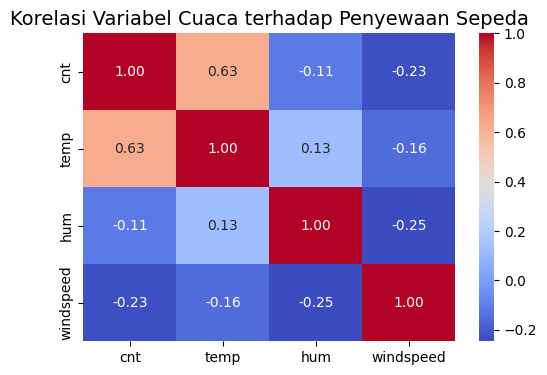

In [178]:
corr_weather = day_df[['cnt','temp','hum','windspeed']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr_weather, annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Korelasi Variabel Cuaca terhadap Penyewaan Sepeda', fontsize=14)

plt.show()

### Pertanyaan 2: Bagaimana perbandingan rata-rata penyewaan sepeda antara hari libur dan hari kerja?

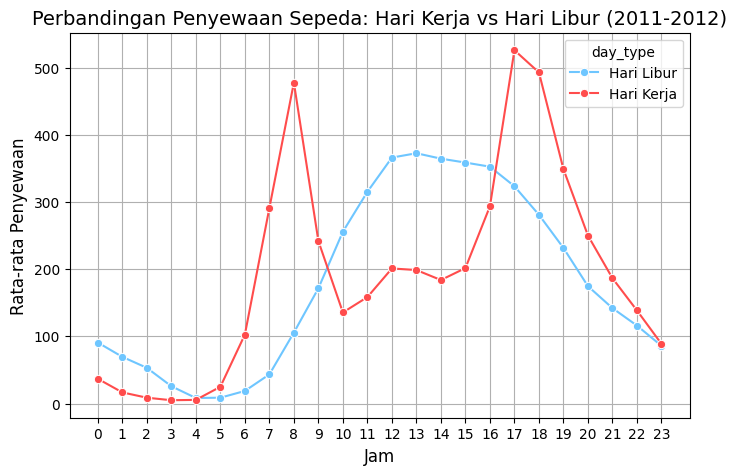

In [179]:
hourly_working['day_type'] = hourly_working['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})

plt.figure(figsize=(8,5))

sns.lineplot(data=hourly_working, x='hr', y='cnt', hue='day_type',
             marker='o', palette={'Hari Libur': '#6EC6FF', 'Hari Kerja': '#FF4C4C'})

plt.title('Perbandingan Penyewaan Sepeda: Hari Kerja vs Hari Libur (2011-2012)', fontsize=14)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)
plt.xticks(range(0,24))
plt.grid(True)
plt.show()

/tmp/ipykernel_26559/3157139798.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('workingday')['cnt']
/tmp/ipykernel_26559/3157139798.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


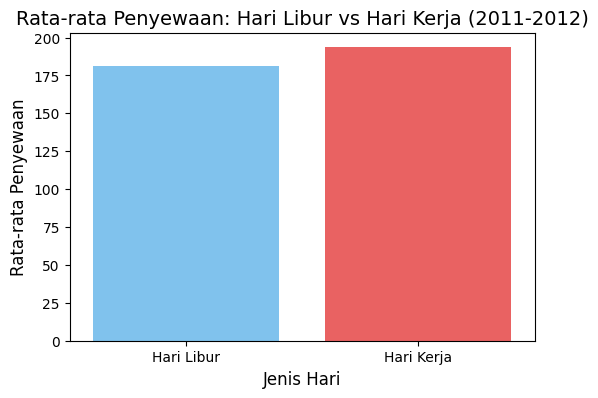

In [180]:
avg_comparison = (
    hour_df
    .groupby('workingday')['cnt']
    .mean()
    .reset_index()
)

plt.figure(figsize=(6,4))

sns.barplot(
    data=avg_comparison,
    x='workingday',
    y='cnt',
    palette=['#6EC6FF', '#FF4C4C']
)

plt.title('Rata-rata Penyewaan: Hari Libur vs Hari Kerja (2011-2012)', fontsize=14)
plt.xlabel('Jenis Hari', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)

plt.xticks([0,1], ['Hari Libur', 'Hari Kerja'])

plt.show()

/tmp/ipykernel_26559/2525874635.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=day_df, x='day_type', y='cnt',


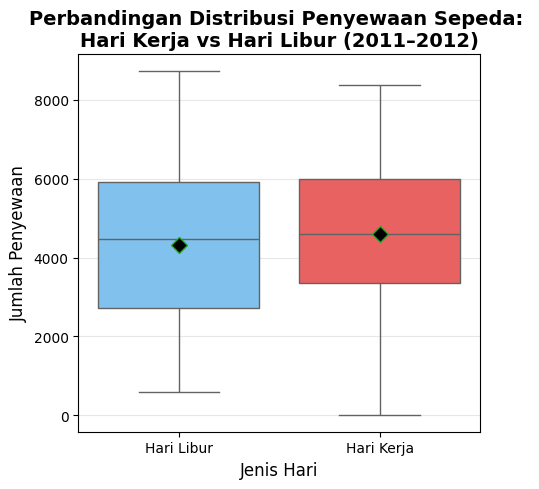

In [181]:
day_df['day_type'] = day_df['workingday'].map({0: 'Hari Libur', 1: 'Hari Kerja'})
plt.figure(figsize=(5,5))

sns.boxplot(data=day_df, x='day_type', y='cnt',
            palette=['#6EC6FF', '#FF4C4C'],
            showmeans=True, meanprops={'marker': 'D', 'markerfacecolor': 'black', 'markersize': 8})

plt.title('Perbandingan Distribusi Penyewaan Sepeda: \nHari Kerja vs Hari Libur (2011–2012)',
          fontsize=14, fontweight='bold')
plt.xlabel('Jenis Hari', fontsize=12)
plt.ylabel('Jumlah Penyewaan', fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Pertanyaan 3: Kapan terjadi rata-rata jumlah penyewaan sepeda tertinggi dan terendah dalam sehari?




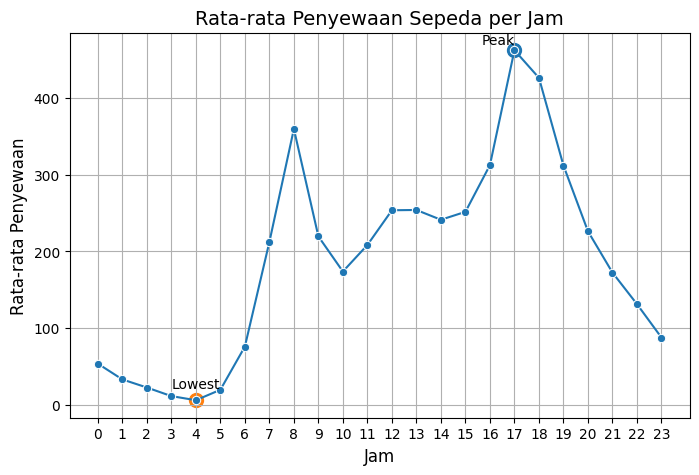

In [182]:
hourly_mean_sorted = hourly_mean.sort_values('hr')

plt.figure(figsize=(8,5))

sns.lineplot(data=hourly_mean_sorted, x='hr', y='cnt', marker='o')

plt.title('Rata-rata Penyewaan Sepeda per Jam', fontsize=14)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)

plt.scatter(peak_hour['hr'], peak_hour['cnt'], s=100)
plt.text(peak_hour['hr'], peak_hour['cnt']+8, 'Peak', ha='right')

plt.scatter(lowest_hour['hr'], lowest_hour['cnt'], s=100)
plt.text(lowest_hour['hr'], lowest_hour['cnt']+15, 'Lowest', ha='center')

plt.xticks(range(0,24))
plt.grid(True)

plt.show()

/tmp/ipykernel_26559/3579396308.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


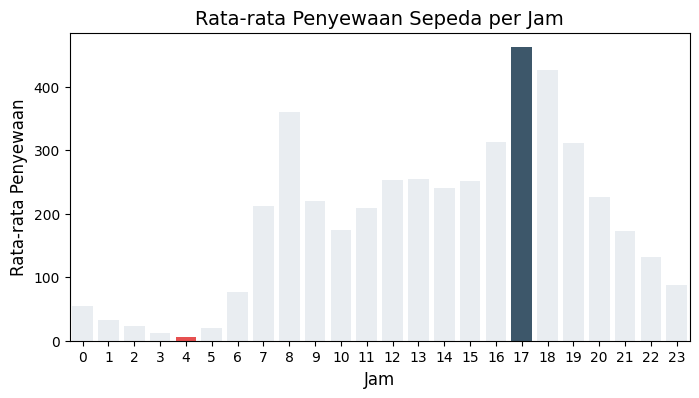

In [183]:
colors = [
    '#355872' if row['hr'] == peak_hour['hr']
    else '#FF3737' if row['hr'] == lowest_hour['hr']
    else '#E8EDF2'
    for _, row in hourly_mean_sorted.iterrows()
]

plt.figure(figsize=(8,4))

sns.barplot(
    data=hourly_mean_sorted,
    x='hr',
    y='cnt',
    palette=colors
)

plt.title('Rata-rata Penyewaan Sepeda per Jam', fontsize=14)
plt.xlabel('Jam', fontsize=12)
plt.ylabel('Rata-rata Penyewaan', fontsize=12)

plt.show()

**Insight:**
1. **Pengaruh kondisi cuaca terhadap penyewaan sepeda**
- Rata-rata penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah (Clear) dan menurun pada kondisi berawan (Mist/Cloudy) serta paling rendah pada hujan/salju ringan, menunjukkan bahwa cuaca yang lebih baik mendorong peningkatan penggunaan sepeda.
- Visualisasi hubungan suhu menunjukkan tren positif, di mana semakin tinggi suhu (dalam °C), jumlah penyewaan sepeda cenderung meningkat secara signifikan.
- Kelembapan memiliki kecenderungan hubungan negatif lemah, di mana peningkatan kelembapan diikuti dengan penurunan jumlah penyewaan, terutama pada tingkat kelembapan yang tinggi.
- Kecepatan angin juga menunjukkan pengaruh negatif, di mana angin yang lebih kencang cenderung menurunkan minat pengguna untuk menyewa sepeda.
- Heatmap korelasi memperkuat temuan bahwa:
  - suhu memiliki hubungan paling kuat terhadap penyewaan (positif)
  - kelembapan dan kecepatan angin memiliki hubungan negatif namun relatif lemah
- Secara keseluruhan, faktor cuaca yang paling berpengaruh terhadap penyewaan sepeda adalah suhu, diikuti oleh kelembapan dan kecepatan angin sebagai faktor penghambat.

2. **Perbandingan hari kerja vs hari libur**
- Rata-rata penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur, yang menunjukkan dominasi penggunaan untuk aktivitas rutin seperti bekerja atau sekolah.
- Pola penyewaan pada hari kerja menunjukkan dua puncak utama, yaitu pada pagi dan sore hari, yang mencerminkan pola mobilitas komuter.
- Pada hari libur, pola penyewaan cenderung lebih landai dan terpusat pada siang hari, menunjukkan penggunaan untuk aktivitas rekreasi.
- Boxplot menunjukkan bahwa distribusi penyewaan pada hari kerja memiliki nilai tengah (median) yang lebih tinggi, meskipun variasi data pada kedua jenis hari cukup besar.
- Secara umum, penyewaan sepeda pada hari kerja lebih konsisten dan tinggi, sedangkan pada hari libur lebih fleksibel dan bergantung pada waktu luang pengguna.

3. **Waktu dengan penyewaan tertinggi dan terendah**
- Rata-rata penyewaan sepeda tertinggi terjadi pada pukul 17.00, yang mengindikasikan peningkatan penggunaan pada waktu pulang kerja (evening rush hour).
- Rata-rata penyewaan sepeda terendah terjadi pada pukul 04.00, yang menunjukkan aktivitas penggunaan sangat rendah pada dini hari.
- Pola penyewaan per jam membentuk tren yang jelas, yaitu:
  - meningkat mulai pagi hari
  - mencapai puncak pada sore hari
  - menurun kembali pada malam hingga dini hari
- Visualisasi tambahan menunjukkan bahwa jam puncak dan jam terendah konsisten meskipun dilihat dengan pendekatan grafik yang berbeda (line plot dan barplot).
- Secara keseluruhan, pola ini mencerminkan ritme aktivitas harian masyarakat, dengan penggunaan tertinggi pada jam produktif dan terendah saat waktu istirahat.

## Analisis Lanjutan (Opsional)

In [184]:
hourly_mean_sorted['usage_category'] = pd.cut(
    hourly_mean_sorted['cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

hourly_mean_sorted

,hr,cnt,usage_category
0,0,53.968276,Low
1,1,33.419087,Low
2,2,22.900560,Low
3,3,11.727403,Low
4,4,6.352941,Low
5,5,19.913408,Low
6,6,76.132597,Low
7,7,212.305785,Medium
8,8,359.444904,High
9,9,219.578512,Medium


In [185]:
weather_daily['usage_category'] = pd.cut(
    weather_daily['mean_cnt'],
    bins=3,
    labels=['Low', 'Medium', 'High']
)

weather_daily

,weather_label,mean_cnt,median_cnt,min_cnt,max_cnt,n,usage_category
0,Clear,4876.786177,4844.0,431,8714,463,High
1,Mist/Cloudy,4035.862348,4040.0,605,8362,247,High
2,Light Rain/Snow,1862.300000,1829.5,22,4639,20,Low


In [186]:
day_df['temp_category'] = pd.cut(
    day_df['temp_c'],
    bins=[0,15,25,35],
    labels=['Low','Medium','High']
)

temp_cluster = (
    day_df
    .groupby('temp_category', observed=True)['cnt']
    .mean()
    .reset_index()
    .sort_values('temp_category')
)

temp_cluster

,temp_category,cnt
0,Low,2833.316742
1,Medium,4879.835206
2,High,5635.423237


In [196]:
main_data = hour_df.copy()
main_data.to_csv("main_data.csv", index=False)

## Conclusion

- **Conclution pertanyaan 1 : Bagaimana pengaruh variabel kondisi cuaca terhadap jumlah total penyewaan sepeda per hari?**
  
  Kondisi cuaca memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda. Penyewaan cenderung lebih tinggi pada cuaca cerah maupun berawan ringan, dan menurun drastis pada kondisi hujan atau salju ringan. Selain itu, suhu berperan sebagai faktor paling dominan, dengan kecenderungan bahwa semakin tinggi suhu, semakin tinggi pula jumlah penyewaan, sedangkan kelembapan dan kecepatan angin memberikan pengaruh negatif.
- **Conclution pertanyaan 2 : Bagaimana perbandingan rata-rata penyewaan sepeda antara hari libur dan hari kerja?**
  
  Rata-rata penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur, yang menunjukkan bahwa layanan bike sharing lebih banyak dimanfaatkan untuk aktivitas rutin, seperti mobilitas kerja atau sekolah. Pada hari kerja, pola penyewaan membentuk puncak yang jelas pada pagi dan sore hari, sedangkan pada hari libur pola penggunaan lebih tersebar dan cenderung terjadi pada siang hari.
- **Conclution pertanyaan 3 : Kapan terjadi rata-rata jumlah penyewaan sepeda tertinggi dan terendah dalam sehari?**
  
  Berdasarkan analisis waktu, rata-rata penyewaan sepeda tertinggi terjadi pada pukul 17.00, yang mencerminkan peningkatan penggunaan pada jam pulang kerja. Sebaliknya, rata-rata penyewaan terendah terjadi pada pukul 04.00, yang menunjukkan minimnya aktivitas pada dini hari. Pola ini menunjukkan adanya siklus harian yang konsisten, di mana penggunaan meningkat pada jam produktif dan menurun pada waktu istirahat.
